In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

## Carga de datos:

In [2]:
train_data = pd.read_csv('../data/raw/train.csv')
test_data = pd.read_csv('../data/raw/test.csv')

## Revisión de datos:

In [3]:
# Cantidad de filas y columnas de train_data (rows, cols)

train_data.shape

(891, 12)

In [4]:
# Revisar las variables que puedan tener valores faltantes de train_data

train_data.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [5]:
#Revisar si hay valores vacíos en train_data. Age tiene 177 valores vacíos. 
# #Se calculará el promdio de edades en el barco para llenar estos espacios vacíos.

train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
#Calcular el promedio de las edades en el barco.

train_data['Age'].mean()

29.69911764705882

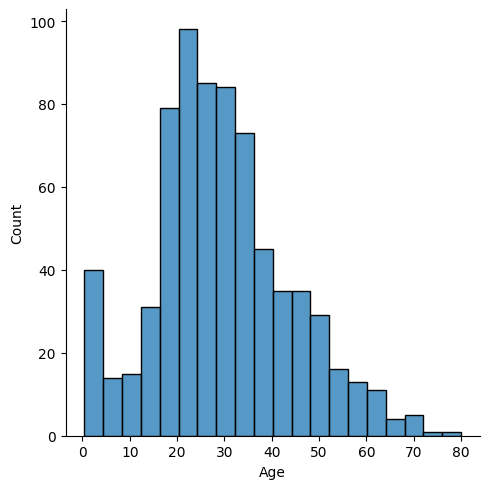

In [7]:
#Observar la distribución de las edades en el barco.

sns.displot(x='Age', data=train_data)
plt.show()

In [8]:
# Llenar los valores vacíos con el promedio de edades.

train_data['Age']=train_data['Age'].fillna(train_data['Age'].mean())
print(train_data.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
#La columna 'Cabin' al tener casi todos los valores vacíos, será eliminada.

train_data=train_data.drop(['Cabin'], axis=1)

In [10]:
# Eliminar los datos vacíos de la columna Embarked

train_data = train_data.dropna()

In [11]:
#La variable objetivo está balanceada?

train_data['Survived'].value_counts(normalize=True)

Survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

In [12]:
#Cinco primeras filas del conjunto de datos de train_data

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [13]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 83.3 KB


In [14]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.653446,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,12.968366,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Visualizaciones 

In [15]:
# Pclass vs Survived
train_data.groupby('Pclass')['Survived'].mean()

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64

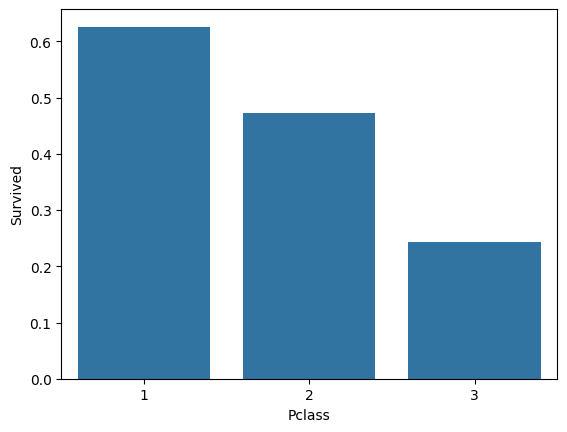

In [16]:
# Pclass vs Survived
sns.barplot(
    data=train_data,
    x = 'Pclass',
    y = 'Survived',  
    errorbar=None 
)
plt.show()

In [17]:
# Gender vs Survived
train_data.groupby('Sex')['Survived'].mean()

Sex
female    0.740385
male      0.188908
Name: Survived, dtype: float64

<Axes: xlabel='Sex', ylabel='Survived'>

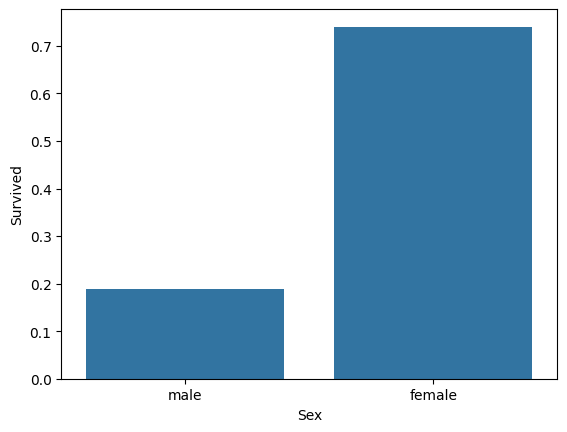

In [18]:
sns.barplot(
    data=train_data,
    x='Sex',
    y='Survived',
    errorbar=None
)

<Axes: xlabel='Survived', ylabel='count'>

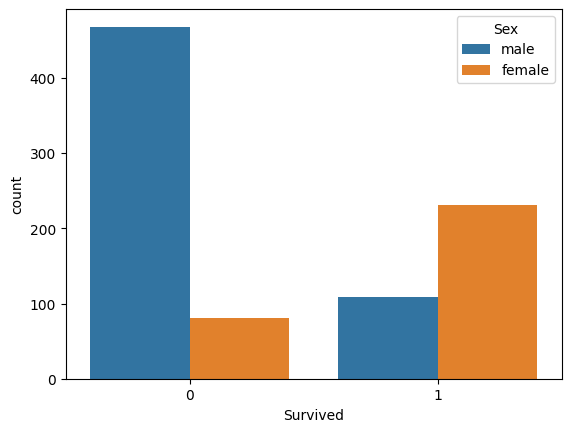

In [19]:
sns.countplot(x='Survived', data=train_data, hue='Sex')

In [20]:
#Mirar los datos de la columna 'Embarked'

train_data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

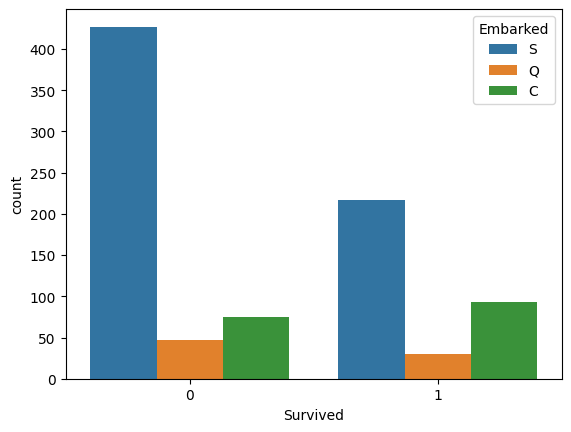

In [21]:
sns.countplot(
    x='Survived',
    data=train_data,
    hue='Embarked'
)

In [22]:
#Convertir la columna Embarked a valores numéricos y eliminar una de sus columnas para no ser redundante

embarked_durmmies = pd.get_dummies((train_data['Embarked']),drop_first=True).astype(int)
embarked_durmmies


,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
886,0,1
887,0,1
888,0,1
889,0,0


In [23]:
#Agregar a train_data dummies_embarked y eliminar Embarked
train_data=train_data.join(embarked_durmmies)
train_data = train_data.drop(['Embarked'], axis = 1)

In [24]:
#Convertir la columna 'Sex' a datos numéricos y eliminar una de las columnas para no ser redundantes

dummies_sex = pd.get_dummies((train_data['Sex']), drop_first=True).astype(int)
dummies_sex

,male
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [25]:
#Agrega dummies_sex a train_data  y eliminar la columna 'Sex'

train_data = train_data.join(dummies_sex)
train_data = train_data.drop(['Sex'],axis=1)


In [26]:
#Eliminar columnas que no aportan al modelo como 'PassengerId', 'Name', 'Ticket'

train_data=train_data.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

In [27]:
train_data.head(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,Q,S,male
0,0,3,22.000000,1,0,7.2500,0,1,1
1,1,1,38.000000,1,0,71.2833,0,0,0
2,1,3,26.000000,0,0,7.9250,0,1,0
3,1,1,35.000000,1,0,53.1000,0,1,0
4,0,3,35.000000,0,0,8.0500,0,1,1
5,0,3,29.699118,0,0,8.4583,1,0,1
6,0,1,54.000000,0,0,51.8625,0,1,1
7,0,3,2.000000,3,1,21.0750,0,1,1
8,1,3,27.000000,0,2,11.1333,0,1,0
9,1,2,14.000000,1,0,30.0708,0,0,0


<Axes: >

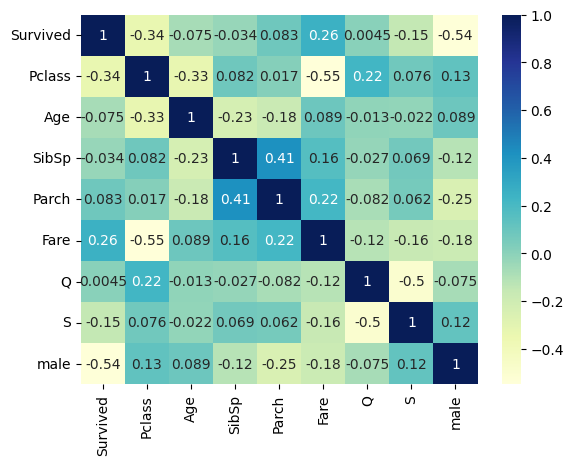

In [28]:
#Observar las correlaciones entre variables mediante el mapa de calor

sns.heatmap(
    train_data.corr(),
    annot=True,
    cmap='YlGnBu'
)

In [29]:
# Age vs Survived
train_data.groupby(pd.cut(train_data['Age'], bins = 10))['Survived'].mean()

Age
(0.34, 8.378]       0.666667
(8.378, 16.336]     0.413043
(16.336, 24.294]    0.355932
(24.294, 32.252]    0.338150
(32.252, 40.21]     0.435897
(40.21, 48.168]     0.342857
(48.168, 56.126]    0.466667
(56.126, 64.084]    0.347826
(64.084, 72.042]    0.000000
(72.042, 80.0]      0.500000
Name: Survived, dtype: float64

In [30]:
# SibSp vs Survived

train_data.groupby('SibSp')['Survived'].mean()

SibSp
0    0.343234
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

In [31]:
#Parch vs Survived

train_data.groupby('Parch')['Survived'].mean()

Parch
0    0.341716
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

In [32]:
# Fare vs Survived
train_data.groupby('Fare')['Survived'].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 247, dtype: float64

In [33]:
train_data[['Pclass', 'Fare']].corr(numeric_only=True)

,Pclass,Fare
Pclass,1.000000,-0.548193
Fare,-0.548193,1.000000


In [34]:
# Features
features = [
    'Sex',
    'Pclass',
    'Age',
    'Fare',
]
X = train_data[features]
X_test = train_data[features]
y = train_data['Survived']

KeyError: "['Sex'] not in index"

In [ ]:
#Categorical variables

X = pd.get_dummies(X)
X_test = pd.get_dummies(X_test)

In [ ]:
#Align columns

X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)